In [2]:
import pandas as pd
import numpy as np

def calculate_monthly_carbon_emissions(df: pd.DataFrame):
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["dt_hours"] = df["dt_hours"].bfill()

    df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]

    df["carbon_g"] = df["energy_kWh"] * df["carbon_intensity_gco2_per_kwh"]

    df["date"] = df["timestamp"].dt.date
    daily = df.groupby("date")["carbon_g"].sum().reset_index()

    daily["date"] = pd.to_datetime(daily["date"])
    daily["month"] = daily["date"].dt.month

    data = [
        daily[daily["month"] == m]["carbon_g"].values
        for m in range(1, 13)
    ]

    return data


df_bang = pd.read_csv("data/bang.csv")
df_mpc_carbon = pd.read_csv("data/room_alg_co2.csv")
df_mpc_without_carbon = pd.read_csv("data/room_alg_no_co2.csv")

monthly_data_bang = calculate_monthly_carbon_emissions(df_bang)
monthly_data_mpc_carbon = calculate_monthly_carbon_emissions(df_mpc_carbon)
monthly_data_mpc_without_carbon = calculate_monthly_carbon_emissions(df_mpc_without_carbon)

averaged_monthly_data_bang = [np.mean(month) for month in monthly_data_bang]
averaged_monthly_data_mpc_carbon = [np.mean(month) for month in monthly_data_mpc_carbon]
averaged_monthly_data_mpc_without_carbon = [np.mean(month) for month in monthly_data_mpc_without_carbon]

datasets = {'Bang': averaged_monthly_data_bang, 'MPC with carbon': averaged_monthly_data_mpc_carbon, 'MPC without carbon': averaged_monthly_data_mpc_without_carbon}

In [3]:
import matplotlib.pyplot as plt
from scipy import stats

# Each dataset contains twelve values (averages per month), so Shapiro-Wilk can be used (n<50)
# print("--- Shapiro-Wilk Normality Test Results ---")
# for name, data in datasets.items():
#     stat, p_val = stats.shapiro(data)
#
#     print(f"\t{name}: p-value = {p_val:.4f}")
#
#     if p_val > 0.05:
#         print("\t\tResult: Likely Normal (Fail to reject H0)")
#     else:
#         print("\t\tResult: NOT Normal (Reject H0)")
#
#     print("\r")


In [4]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Primary Significance Test (one-way ANOVA)
# Since data is normal, we can use the ANOVA
# f_stat, p_val = stats.f_oneway(averaged_monthly_data_bang, averaged_monthly_data_mpc_carbon, averaged_monthly_data_mpc_without_carbon)
#
# print(f"One-way ANOVA p-value = {p_val:.4f}")
#
# if p_val < 0.05:
#     print("Significant difference found! Running post-hoc test...")
#
#     # Post-hoc Analysis (Tukey's HSD)
#     # Reformat data for statsmodels: score column and group label column
#     df = pd.DataFrame({
#         'score': averaged_monthly_data_bang + averaged_monthly_data_mpc_carbon + averaged_monthly_data_mpc_without_carbon,
#         'group': ['A']*len(averaged_monthly_data_bang) + ['B']*len(averaged_monthly_data_mpc_carbon) + ['C']*len(averaged_monthly_data_mpc_without_carbon)
#     })
#
#     posthoc = pairwise_tukeyhsd(df['score'], df['group'], alpha=0.05)
#
#     print(posthoc.summary())
#     print(posthoc)
# else:
#     print("No significant difference between algorithms.")

Model's residuals: 0      -3819.031778
1      -1002.414903
2      -1276.907903
3        849.426847
4      -2925.356653
           ...     
1093   -2339.970406
1094   -2339.970406
1095   -2339.970406
1096   -2339.970406
1097   -2339.970406
Length: 1098, dtype: float64



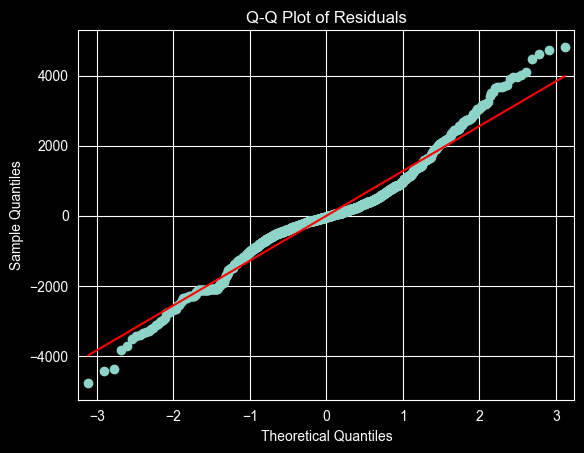

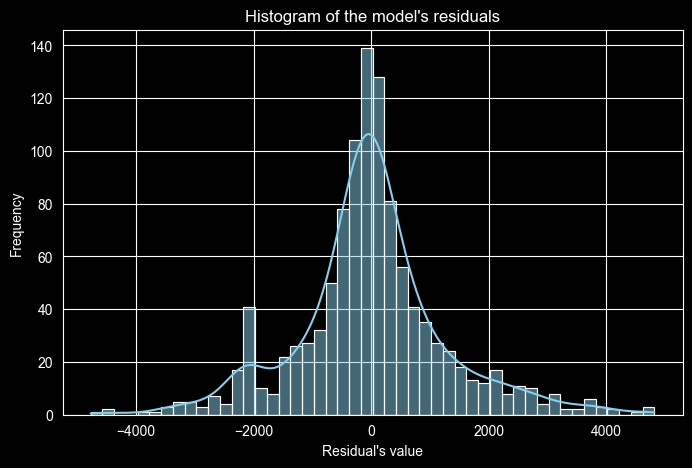

In [8]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns

# Create a helper function to flatten monthly lists into a DataFrame
def prepare_for_anova(monthly_list, algo_name):
    rows = []
    # Loop through each month
    for month_idx, month_values in enumerate(monthly_list):
        month_num = month_idx + 1
        for val in month_values:
            rows.append({
                'emissions': val,
                'algorithm': algo_name,
                'month': month_num
            })
    return pd.DataFrame(rows)

# Convert all three datasets
df_bang = prepare_for_anova(monthly_data_bang, 'Bang')
df_mpc_c = prepare_for_anova(monthly_data_mpc_carbon, 'MPC_Carbon')
df_mpc_nc = prepare_for_anova(monthly_data_mpc_without_carbon, 'MPC_No_Carbon')

# Combine them into one "Long Format" DataFrame
df_long = pd.concat([df_bang, df_mpc_c, df_mpc_nc], ignore_index=True)

# Run the Two-Way ANOVA (Randomized Block Design)
# 'C()' tells statsmodels these are categorical variables
# Both factors (Algorithm and Month) should be considered independently
# Emissions are explained using the algorithm AND the month it occurred in
# Seasonal variance shouldn't interfere since it treats each month as its own category
model = ols('emissions ~ C(algorithm) + C(month)', data=df_long).fit()
residuals = model.resid
print(f"Model's residuals: {residuals}\n")

# Check normality using QQ-plot (if points roughly follow line, it can be assumed normal)
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

print("\n")

# Histogram to check normality
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='skyblue')
plt.title("Histogram of the model's residuals")
plt.xlabel("Residual's value")
plt.ylabel("Frequency")
plt.show()

# Shapiro-Wilk does NOT work for such large datasets
# print("--- Shapiro-Wilk Normality Test Results ---")
# stat, p_val = stats.shapiro(residuals)
# print(f"\tShapiro-Wilk test's p-value = {p_val:.4f}")

As of 23-3: even though the data does not seem perfectly normal (see QQ plot and histogram), we may be able to assume normality due to seasonal trends and possible lots of identical data (near-zero emission in summer, for example).

In [6]:
# Run if data is normally distributed

print("\t\tResult: Likely Normal (Fail to reject H0)")

anova_table = sm.stats.anova_lm(model, typ=2)

print("--- Two-Way ANOVA Results ---")
print(anova_table)

# Check significance using two-way ANOVA
p_algo = anova_table.loc['C(algorithm)', 'PR(>F)']

if p_algo < 0.05:
    print(f"\nSignificant difference found (p={p_algo:.4f})!")
    print("Running Tukey HSD to find the most efficient algorithm...")

    # 4. Post-hoc Test
    posthoc = pairwise_tukeyhsd(
        endog=df_long['emissions'],
        groups=df_long['algorithm'],
        alpha=0.05
    )
    print(posthoc.summary())

    # Identify the most efficient algorithm (lowest mean emissions)
    means = df_long.groupby('algorithm')['emissions'].mean()
    print("\nMean Emissions per Algorithm:")
    print(means.sort_values())

else:
    print(f"\nNo significant difference found between algorithms (p={p_algo:.4f}).")


		Result: Likely Normal (Fail to reject H0)
--- Two-Way ANOVA Results ---
                    sum_sq      df           F         PR(>F)
C(algorithm)  3.225671e+07     2.0    9.734912   6.452101e-05
C(month)      1.887333e+09    11.0  103.561396  1.647586e-160
Residual      1.795921e+09  1084.0         NaN            NaN

Significant difference found (p=0.0001)!
Running Tukey HSD to find the most efficient algorithm...
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1       group2     meandiff p-adj    lower    upper   reject
-------------------------------------------------------------------
      Bang    MPC_Carbon -383.9889 0.0131 -702.1723 -65.8055   True
      Bang MPC_No_Carbon -339.0115 0.0335 -657.1949 -20.8281   True
MPC_Carbon MPC_No_Carbon   44.9774 0.9411  -273.206 363.1608  False
-------------------------------------------------------------------

Mean Emissions per Algorithm:
algorithm
MPC_Carbon       1692.681786
MPC_No_Carbon    1737.659184
Ban

In [ ]:
# Run if data is not normally distributed

# print("\t\tResult: NOT Normal (Reject H0)")
# print("Running non-parametric significance test...")
#
# # Non-parametric test (if Shapiro-Wilk shows non-normality)
# stat, p_val = stats.friedmanchisquare(
#     averaged_monthly_data_bang,
#     averaged_monthly_data_mpc_carbon,
#     averaged_monthly_data_mpc_without_carbon
# )
#
# print(f"Friedman Test p-value: {p_val:.4f}")
#
# # Manual Post-hoc using Wilcoxon (if Friedman is significant)
# pairs = [
#     ("Bang vs MPC_C", averaged_monthly_data_bang, averaged_monthly_data_mpc_carbon),
#     ("Bang vs MPC_NC", averaged_monthly_data_bang, averaged_monthly_data_mpc_without_carbon),
#     ("MPC_C vs MPC_NC", averaged_monthly_data_mpc_carbon, averaged_monthly_data_mpc_without_carbon)
# ]
#
# for name, a, b in pairs:
#     _, p = stats.wilcoxon(a, b)
#     # Adjust p-value (Bonferroni: multiply by 3 because we have 3 tests)
#     adj_p = p * 3
#     print(f"{name}: Adjusted p-value = {adj_p:.4f}") # p-value < 0.05 -> significant diff
